# Reproducing *“Designing an Integrated User-Adaptive Future-Self Chatbot for Career Exploration”*

**A one-click reproduction of every result and figure in the thesis.**
Kangzhi Qin · BSc Business Analytics · supporting code for the thesis and for journal submission.

This notebook regenerates the complete evaluation — the sample funnel, all five
between-arm hypothesis tests (Table 2 / Figure 4), the whole-sample pre→post
effects (Figure 6), the manipulation checks and objective Linguistic Style
Matching (Figure 5), the exploratory mediator→outcome coupling (Figure 7), the
coded open-ended evidence (Figures 8–9), reliability, and a set of
**value-adding robustness analyses** (equivalence/TOST, Bayes factors,
minimum-turn sensitivity, multiplicity correction, casing-mirror adherence).

### How it gets the data — automatically, no file upload
The notebook resolves a data source in this order and tells you which it used:

1. **Live PostgreSQL** — if `DATABASE_URL` / `DATABASE_PUBLIC_URL` is set, it reads the study database directly.
2. **Deployed admin export (HTTPS)** — if `STUDY_BASE_URL` + `ADMIN_TOKEN` are set, it pulls the platform's de-identified export.
3. **Bundled snapshot** — otherwise it uses the shipped, **de-identified, numeric-only** snapshot in `data/`, so the notebook runs end-to-end with **zero configuration**.

To use the live database, copy `.env.local.example` → `.env.local` and fill it in (the file is git-ignored). Then *Run All*.

> **Data & ethics.** The bundled snapshot contains **no participant free text** —
> only de-identified numeric survey responses for the 32 analysis participants
> plus precomputed text-derived metrics (LSM, casing, word counts) and
> non-identifying funnel metadata for the other logged sessions. Names, emails,
> transcripts, and open-ended prose are never written to the repository.

## 0 · Setup

In [1]:
# If running fresh, uncomment to install the (light) dependency set:
# %pip install -q numpy pandas scipy statsmodels matplotlib

import os, sys, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

HERE = Path.cwd()
if (HERE / "futureself").exists():
    sys.path.insert(0, str(HERE))
elif (HERE.parent / "futureself").exists():
    sys.path.insert(0, str(HERE.parent))

# load .env.local if present (optional live-DB credentials), without extra deps
envf = next((p for p in [HERE/".env.local", HERE.parent/".env.local"] if p.exists()), None)
if envf:
    for line in envf.read_text().splitlines():
        line = line.strip()
        if line and not line.startswith("#") and "=" in line:
            k, v = line.split("=", 1); os.environ.setdefault(k.strip(), v.strip())
    print("loaded credentials from", envf.name)

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from futureself import cohort, scoring, stats, lsm, qualitative as Q, extensions as X, figures as F
pd.set_option("display.width", 160, "display.max_columns", 40)
print("ready.")

ready.


## 1 · Load the data and apply the registered analysis funnel

The funnel reproduces the thesis §6.4 exactly: of the logged sessions, keep
completed runs on the **final instrument**, restrict to the **direct**
recommendation strategy in both arms (integrated = `main`, baseline =
`baseline`), remove **test / untracked** runs, and exclude runs with **fewer
than two role-play exchanges** — yielding **n = 32 (18 integrated, 14 baseline)**.

In [2]:
studies, source = cohort.load_studies()      # DB -> HTTPS export -> bundled snapshot
sample, counts = cohort.build_funnel(studies)
df = stats.to_frame(sample)

funnel = pd.DataFrame([
    ("Logged sessions",                       counts["logged"]),
    ("Completed",                             counts["completed"]),
    ("… on the final instrument",             counts["completed_final_instrument"]),
    ("… direct strategy, both arms",          counts["direct_strategy_both_arms"]),
    ("… after removing test / untracked",     counts["after_removing_test_untracked"]),
    ("Final analysis sample",                 counts["final_analysis_sample"]),
], columns=["Stage", "n"])
print(f"data source: {source}")
display(funnel)
print("by arm:", counts["_final_by_arm"], "  (thesis: 185 → 32, integrated 18 / baseline 14)")

[futureself] loaded 185 records from bundled de-identified snapshot.
data source: bundled de-identified snapshot


,Stage,n
0,Logged sessions,185
1,Completed,67
2,… on the final instrument,62
3,"… direct strategy, both arms",41
4,… after removing test / untracked,37
5,Final analysis sample,32


by arm: {'integrated': 18, 'baseline': 14}   (thesis: 185 → 32, integrated 18 / baseline 14)


## 2 · Sample description and reliability

In [3]:
def alpha(items):
    A = np.array([r for r in items if all(v is not None for v in r)], float)
    k = A.shape[1]; iv = A.var(axis=0, ddof=1).sum(); tv = A.sum(axis=1).var(ddof=1)
    return k/(k-1)*(1 - iv/tv)
def collect(keys, which):
    return [[ (s.get(which) or {}).get(kk) for kk in keys] for s in sample]
def num(x):
    try: return float(x)
    except: return np.nan

ages = pd.Series([num((s.get('preSurvey') or {}).get('age')) for s in sample]).dropna()
gender = pd.Series([(s.get('preSurvey') or {}).get('gender') for s in sample]).value_counts().to_dict()
fam = df['familiarity'].dropna(); inter = df['interest'].dropna()
agg = {}
p = Path('data/sample_aggregates.json')
if p.exists(): agg = json.loads(p.read_text())

print(f"Age: M={ages.mean():.1f}, SD={ages.std():.1f}, range {int(ages.min())}–{int(ages.max())}")
print(f"Gender: {gender}")
print(f"Familiarity: M={fam.mean():.2f} (SD {fam.std():.2f})   Interest: M={inter.mean():.2f} (SD {inter.std():.2f})")
if agg: print(f"Distinct stated majors: {agg.get('distinct_majors')}")

rel = pd.DataFrame([
    ("Vividness (4 items)",          alpha(collect(scoring.VIV_PRE,'preSurvey')),  alpha(collect(scoring.VIV_POST,'postSurvey'))),
    ("Decision confidence (3 items)",alpha(collect(scoring.CIP_CONF_PRE,'preSurvey')), alpha(collect(scoring.CIP_CONF_POST,'postSurvey'))),
    ("Commitment anxiety (3 items)", alpha(collect(scoring.CIP_ANX_PRE,'preSurvey')),  alpha(collect(scoring.CIP_ANX_POST,'postSurvey'))),
], columns=["Scale","Cronbach α (pre)","Cronbach α (post)"]).round(2)
display(rel)
print("Continuity is a 2-item scale → inter-item r (pre/post):",
      round(np.corrcoef(*np.array([[num(v) for v in r] for r in collect(scoring.FSCS_PRE,'preSurvey') if all(x is not None for x in r)]).T)[0,1],2),
      "/",
      round(np.corrcoef(*np.array([[num(v) for v in r] for r in collect(scoring.FSCS_POST,'postSurvey') if all(x is not None for x in r)]).T)[0,1],2))

Age: M=21.2, SD=2.0, range 18–29
Gender: {'Woman': 20, 'Man': 10, 'Prefer not to say': 2}
Familiarity: M=4.59 (SD 1.16)   Interest: M=5.09 (SD 1.20)
Distinct stated majors: 24


,Scale,Cronbach α (pre),Cronbach α (post)
0,Vividness (4 items),0.90,0.88
1,Decision confidence (3 items),0.87,0.85
2,Commitment anxiety (3 items),0.71,0.67


Continuity is a 2-item scale → inter-item r (pre/post): 0.66 / 0.6


## 3 · Between-arm hypotheses H1–H4b  *(Table 2 / Figure 4)*

For every mediator and outcome, the between-arm difference in pre→post change is
small and non-significant; all five 95% CIs span zero, and four of five point
estimates favour the baseline. The integrated design did **not** outperform the
minimal baseline.

,H,Δ_integrated,Δ_baseline,d,CI,t,df,p
construct,,,,,,,,
closeness,H1,0.39,0.50,-0.10,"[-0.80, +0.60]",-0.28,27.0,0.785
vividness,H2,0.56,0.75,-0.22,"[-0.92, +0.48]",-0.64,30.0,0.527
continuity,H3,-0.22,-0.04,-0.14,"[-0.84, +0.56]",-0.40,30.0,0.693
cip_anxiety,H4a,-0.17,-0.26,0.13,"[-0.57, +0.83]",0.37,30.0,0.715
cip_confidence,H4b,0.06,0.43,-0.51,"[-1.22, +0.20]",-1.42,27.0,0.166


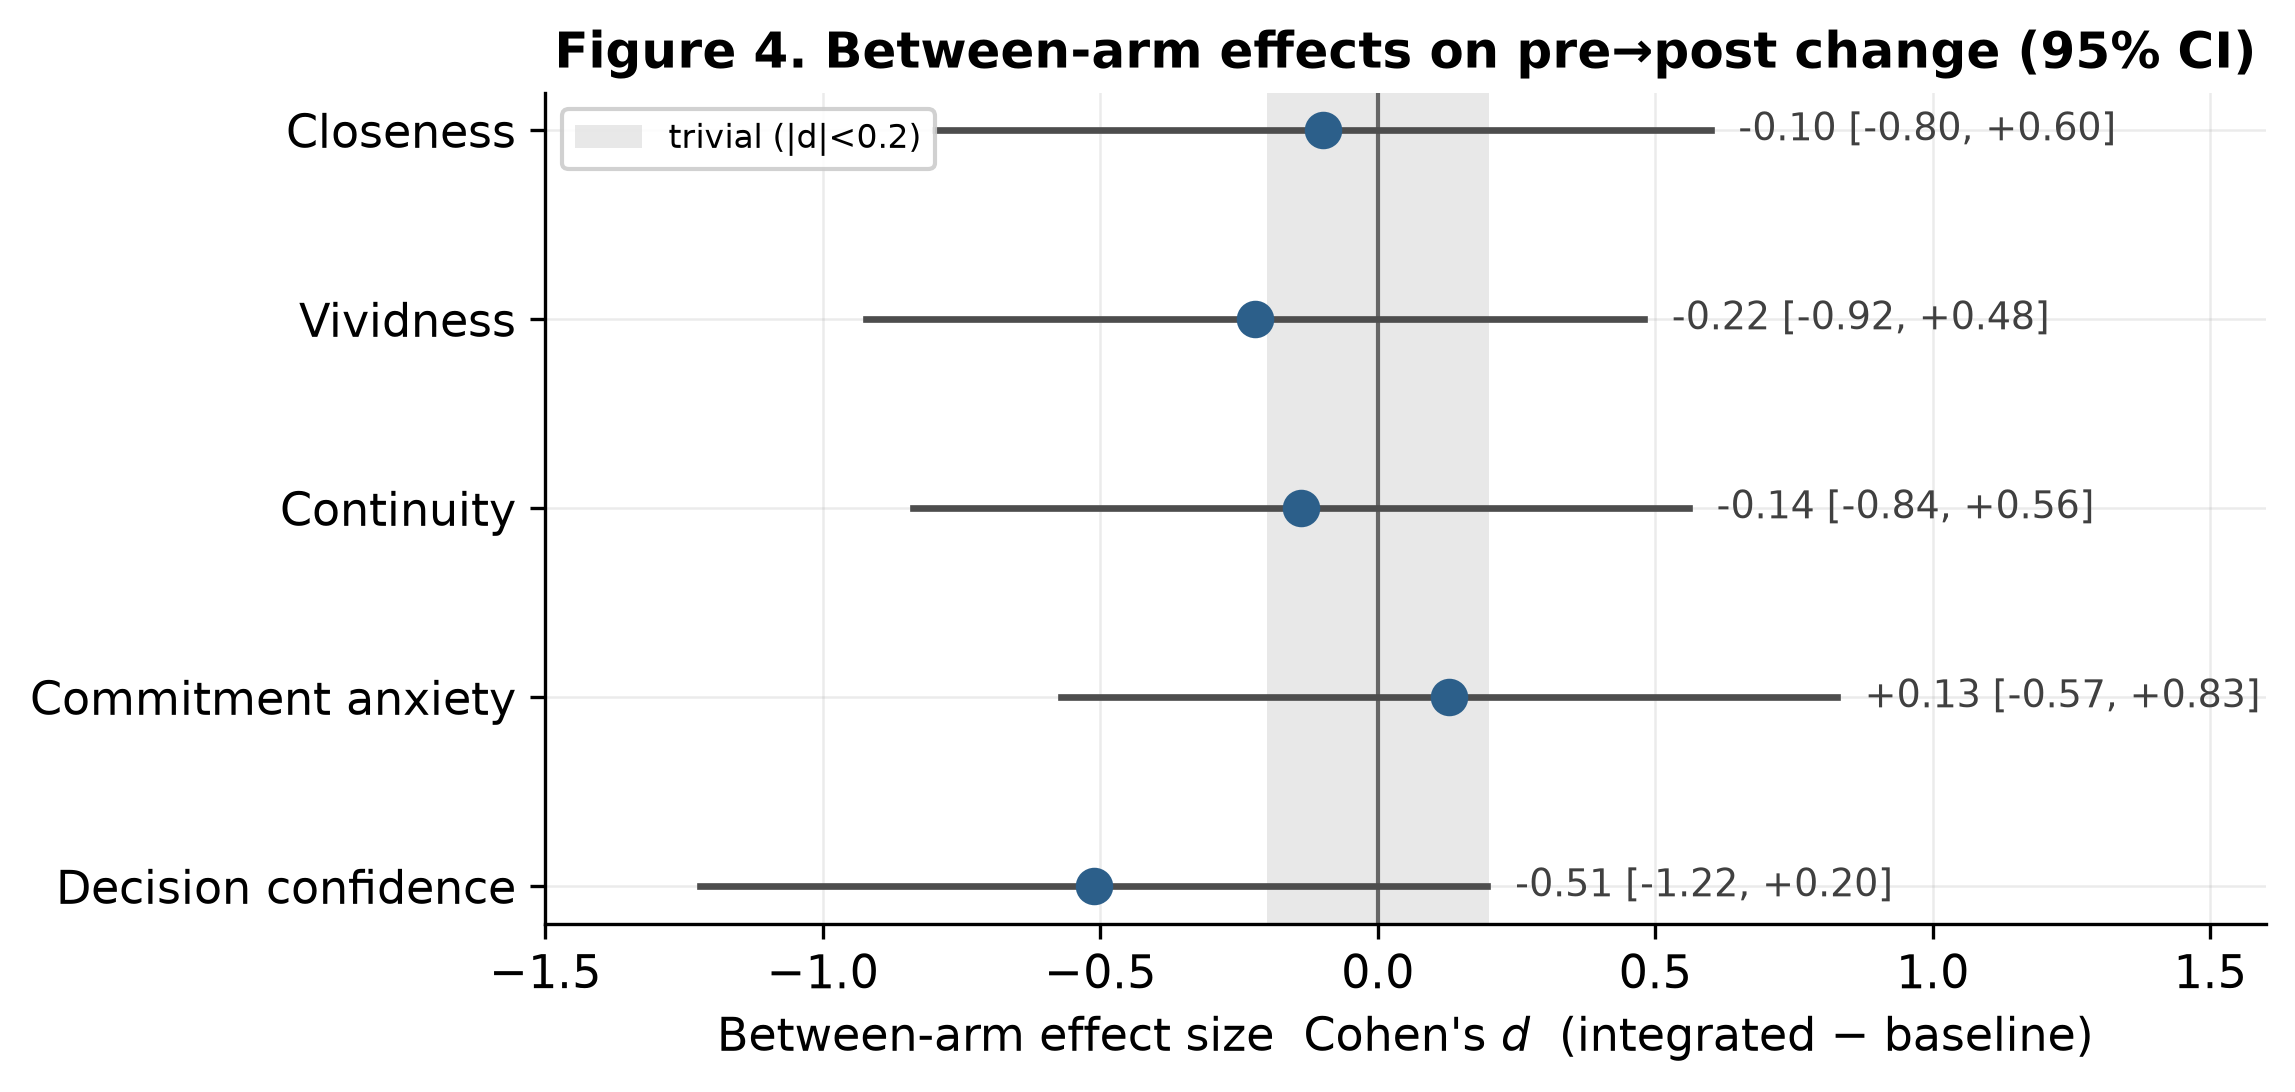

In [4]:
between = stats.between_arms(df)
tab = between.assign(
    Δ_integrated=between.chg_int.round(2), Δ_baseline=between.chg_base.round(2),
    d=between.d.round(2), CI=between.apply(lambda r: f"[{r.ci_lo:+.2f}, {r.ci_hi:+.2f}]", axis=1),
    t=between.t.round(2), df_=between.df.round(0), p=between.p.round(3))
display(tab[["construct","H","Δ_integrated","Δ_baseline","d","CI","t","df_","p"]]
        .rename(columns={"df_":"df"}).set_index("construct"))
F.fig4_between_arm_forest(between);
from IPython.display import Image; Image("figures/fig4_between_arm_forest.png")

## 4 · Whole-sample pre→post change  *(Figure 6)*

Pooling the arms — each delivered a complete future-self conversation — the
session itself raised **vividness** (medium-to-large, p<.001) and **closeness**
(small-to-medium, p<.05). Continuity did not move (it began high); the two
career outcomes shifted in the predicted directions without reaching
significance. So the null concerns the *increment from the adaptive components*,
not the value of the conversation.

,n,pre,post,delta,t,df,p,dz
construct,,,,,,,,
closeness,32,3.88,4.31,0.44,2.24,31,0.032,0.40
vividness,32,3.99,4.63,0.64,4.15,31,0.000,0.73
continuity,32,4.58,4.44,-0.14,-0.60,31,0.553,-0.11
cip_anxiety,32,4.03,3.82,-0.21,-1.61,31,0.118,-0.28
cip_confidence,32,4.24,4.46,0.22,1.67,31,0.105,0.30


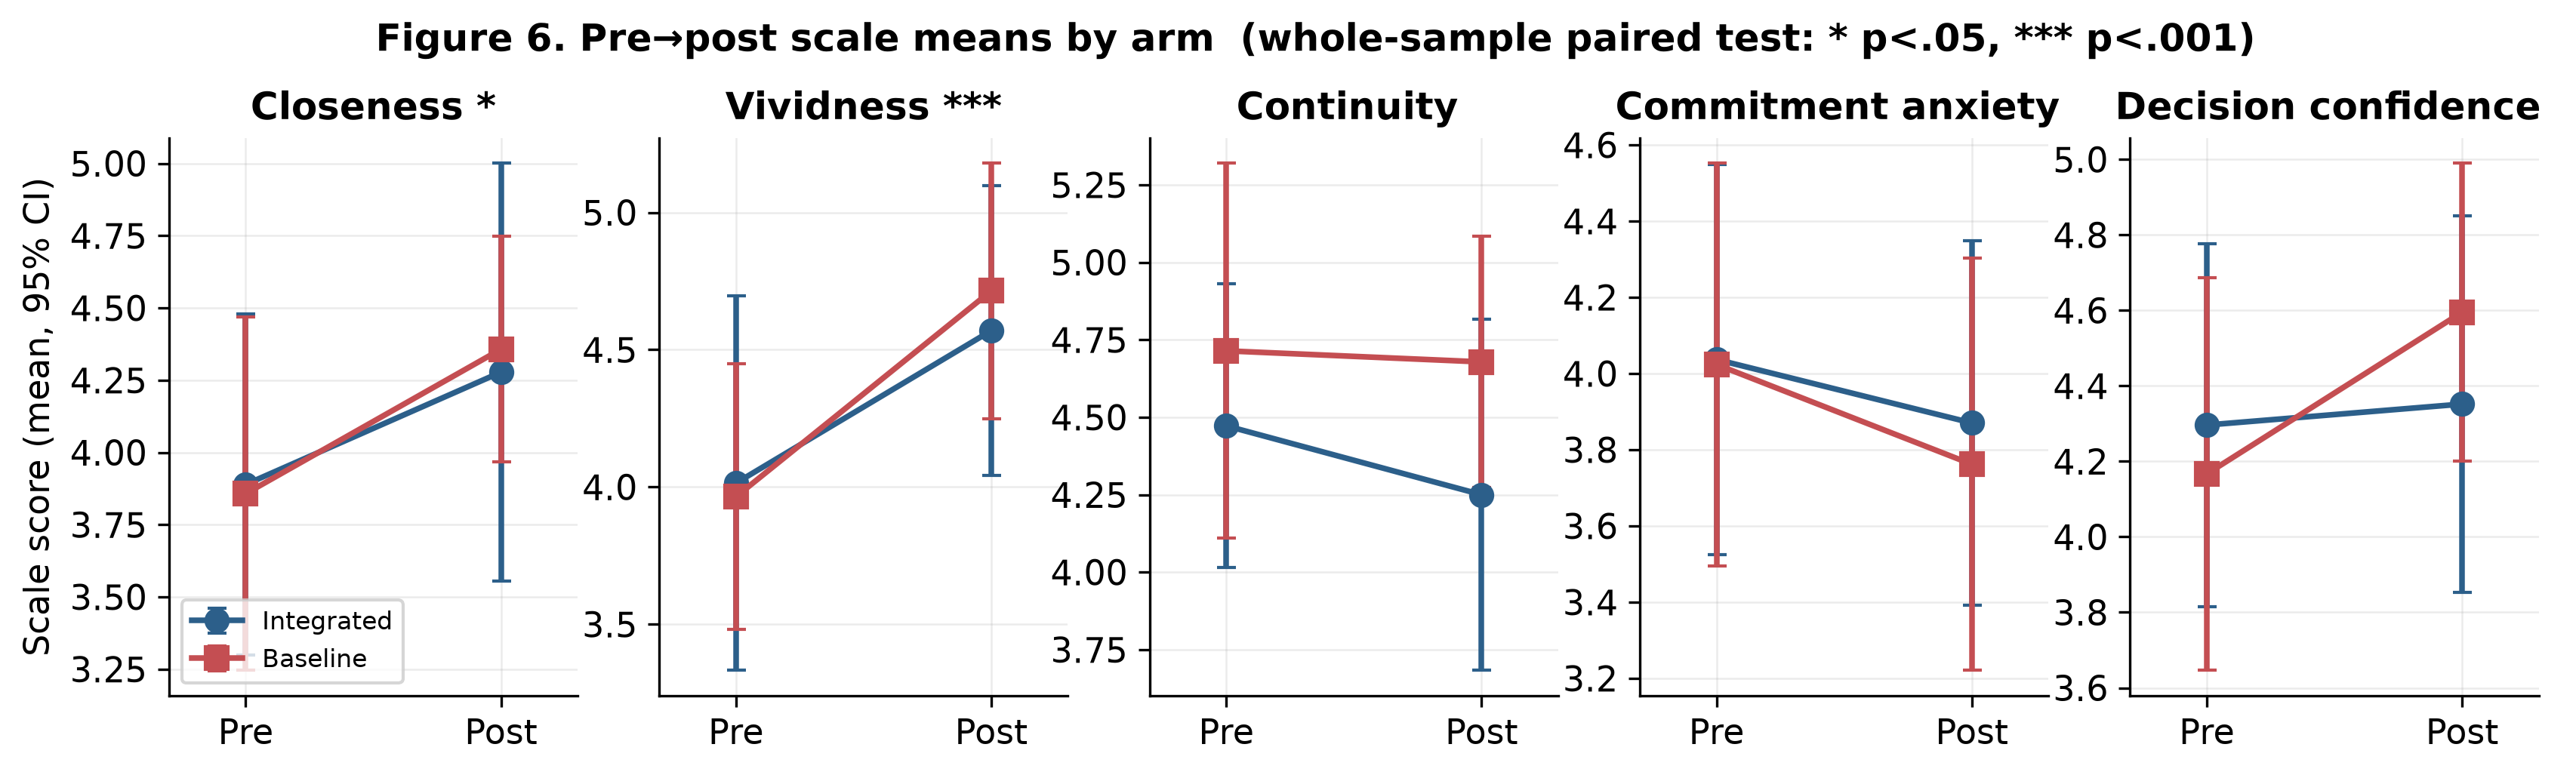

In [5]:
whole = stats.whole_sample_paired(df)
display(whole.assign(pre=whole.pre.round(2), post=whole.post.round(2), delta=whole.delta.round(2),
                     t=whole.t.round(2), p=whole.p.round(3), dz=whole.dz.round(2))
        [["construct","n","pre","post","delta","t","df","p","dz"]].set_index("construct"))
F.fig6_prepost(df, whole); Image("figures/fig6_prepost_by_arm.png")

## 5 · Manipulation checks and objective style matching  *(Figure 5)*

The three manipulation checks did not separate the arms, and an objective
Linguistic Style Matching score (Ireland & Pennebaker, 2010; nine function-word
categories) was near-identical across arms. The components were **barely
perceptible as a difference** — locating the null at the *delivery* of the
components rather than at the theory linking mediators to components.

,mean_int,mean_base,d,p
label,,,,
Felt understood,4.22,4.57,-0.23,0.506
Own way of talking,4.22,4.29,-0.05,0.879
Concrete moments,4.78,4.86,-0.06,0.872


Objective LSM — integrated M=0.63, baseline M=0.61, d=+0.24, p=0.51  (grand mean 0.62)


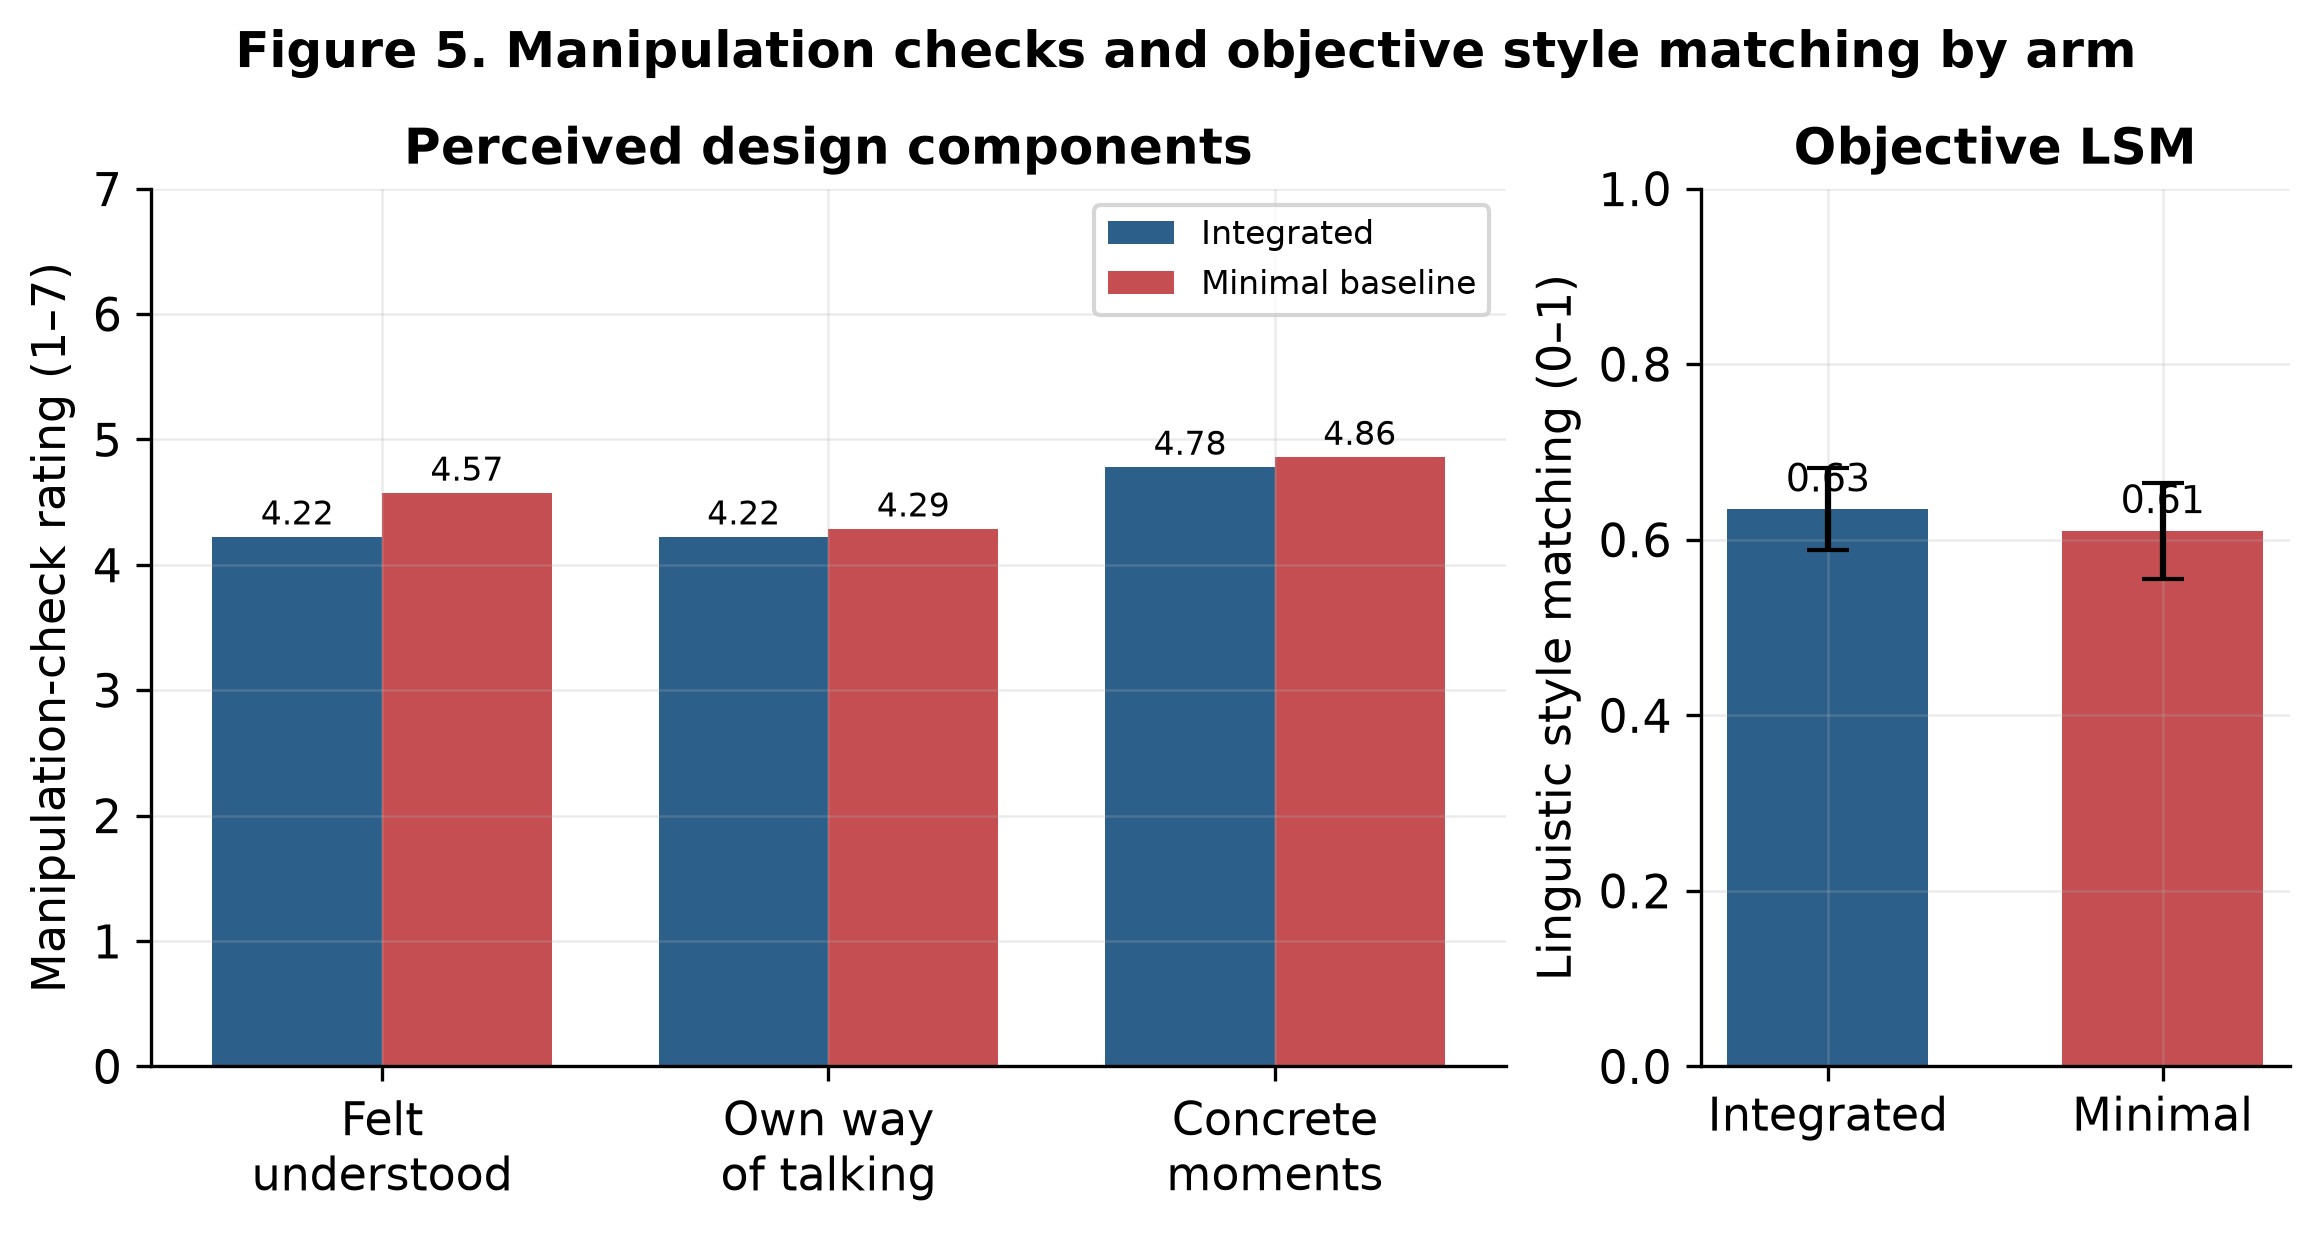

In [6]:
manip = stats.manip_contrasts(df)
display(manip.assign(mean_int=manip.mean_int.round(2), mean_base=manip.mean_base.round(2),
                     d=manip.d.round(2), p=manip.p.round(3))
        [["label","mean_int","mean_base","d","p"]].set_index("label"))
Lr = lsm.lsm_by_arm(sample)
print(f"Objective LSM — integrated M={Lr['integrated_mean']:.2f}, baseline M={Lr['baseline_mean']:.2f}, "
      f"d={Lr['d']:+.2f}, p={Lr['p']:.2f}  (grand mean {(Lr['integrated_mean']*18+Lr['baseline_mean']*14)/32:.2f})")
F.fig5_manip_and_lsm(manip, Lr); Image("figures/fig5_manip_and_lsm.png")

## 6 · Exploratory mediator → outcome coupling  *(Figure 7)*

Change in vividness × change in career self-efficacy: r=+0.31, p=0.09 (pooled, n=32)


,mediator,outcome,r,p,n
0,closeness,cip_confidence,-0.02,0.93,32
1,closeness,cip_anxiety,0.04,0.84,32
2,vividness,cip_confidence,0.31,0.09,32
3,vividness,cip_anxiety,-0.14,0.44,32
4,continuity,cip_confidence,-0.18,0.32,32
5,continuity,cip_anxiety,0.15,0.41,32


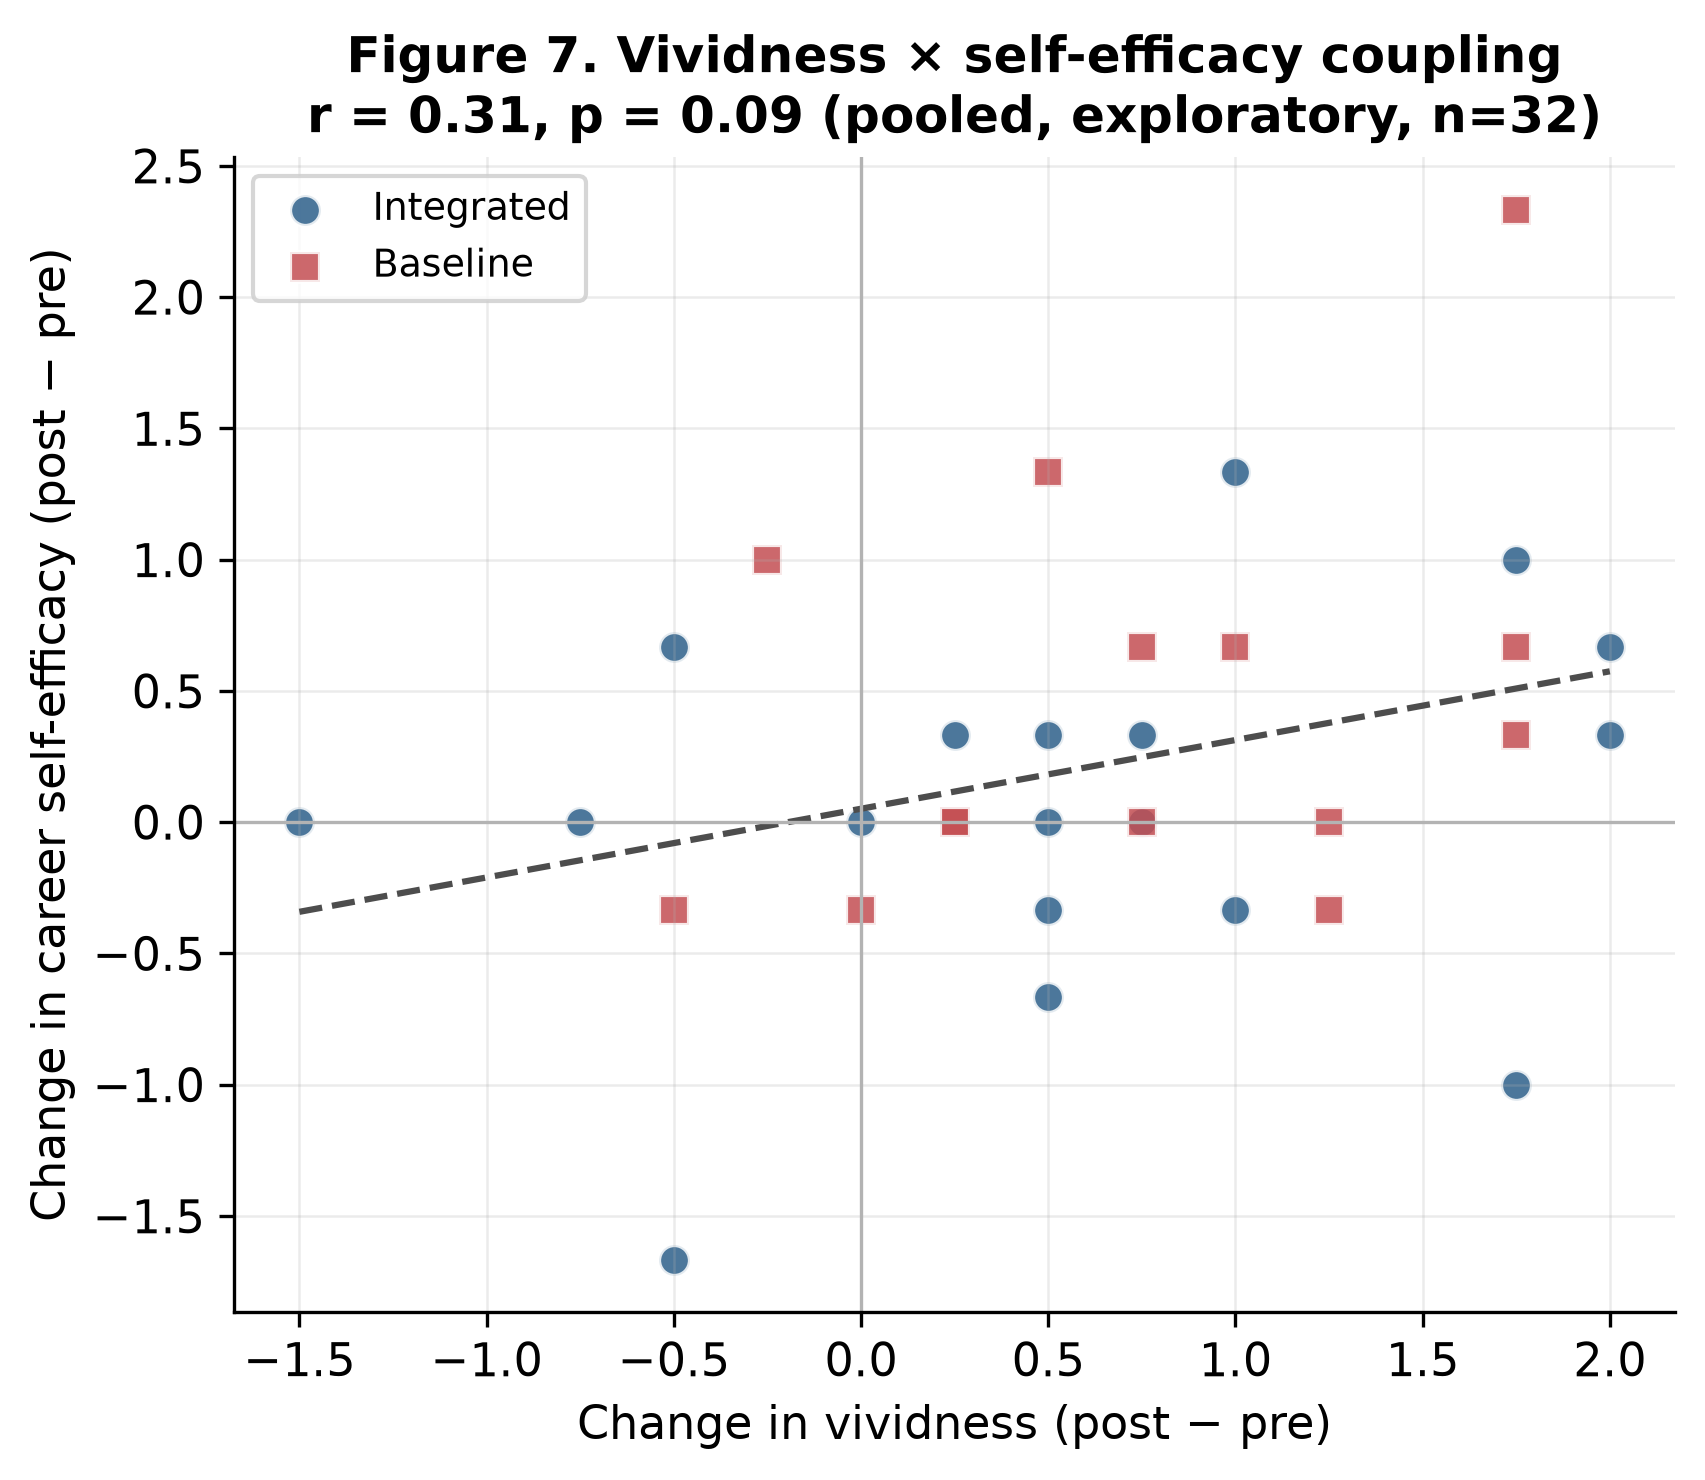

In [7]:
coupling = stats.vividness_selfefficacy_coupling(df)
print(f"Change in vividness × change in career self-efficacy: r={coupling['r']:+.2f}, "
      f"p={coupling['p']:.2f} (pooled, n={coupling['n']})")
display(stats.all_mediator_outcome_corrs(df).round(2))
F.fig7_coupling(df, coupling); Image("figures/fig7_vividness_selfefficacy.png")

## 7 · Coded open-ended evidence  *(Figures 8–9, Table 3)*

Hand-coded from the team's codebook (second coder; Cohen's κ = 1.00 on the
double-coded subset). Restricted to the 32-participant cohort, the integrated
arm carried **more positive codes** (18 vs 11) and **the only vivid-scene
codes** (3 vs 0), and drew **longer** open-ended answers. The shared failure
mode was the drift into generic advice (the immersion break, F3).

Positive codes on 'what felt real' (32 cohort):
  integrated: Σ=18  resonance(P1)=7 vivid(P2)=3 continuity(P3)=8 agency(P5)=0
  baseline  : Σ=11  resonance(P1)=4 vivid(P2)=0 continuity(P3)=5 agency(P5)=2
Inter-rater reliability: Cohen's κ = 1.00 (n=20, 100% agreement)
  integrated: wrote felt-real 15/18 (83%), mean words real=25 broke=30
  baseline  : wrote felt-real 9/14 (64%), mean words real=17 broke=13


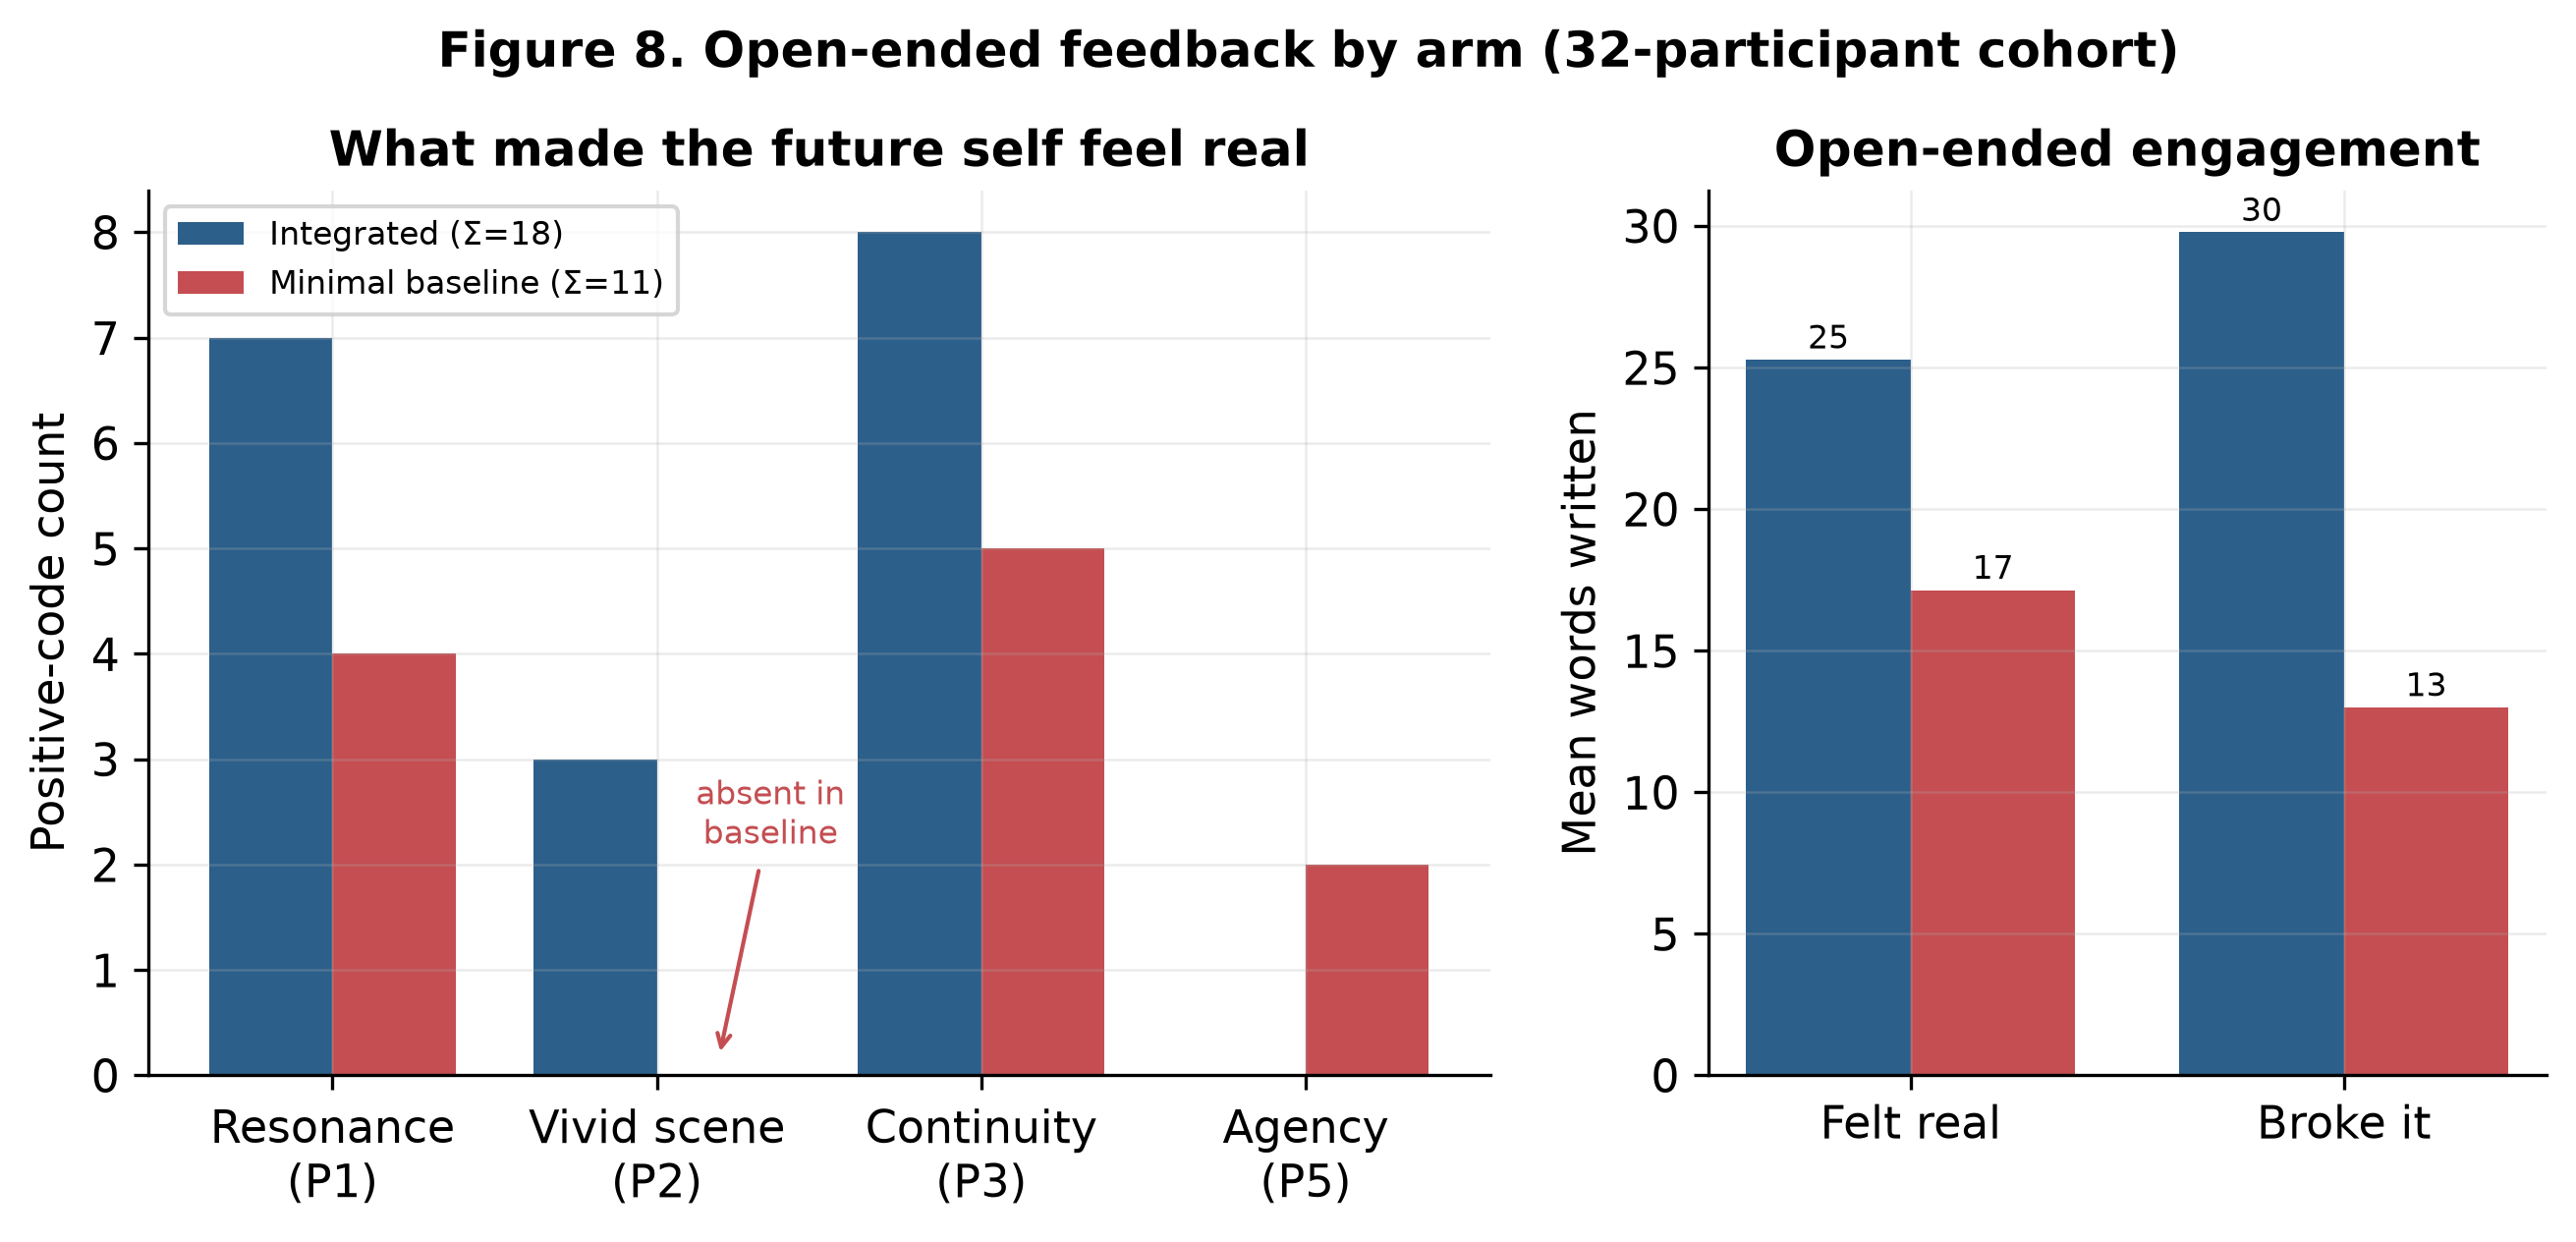

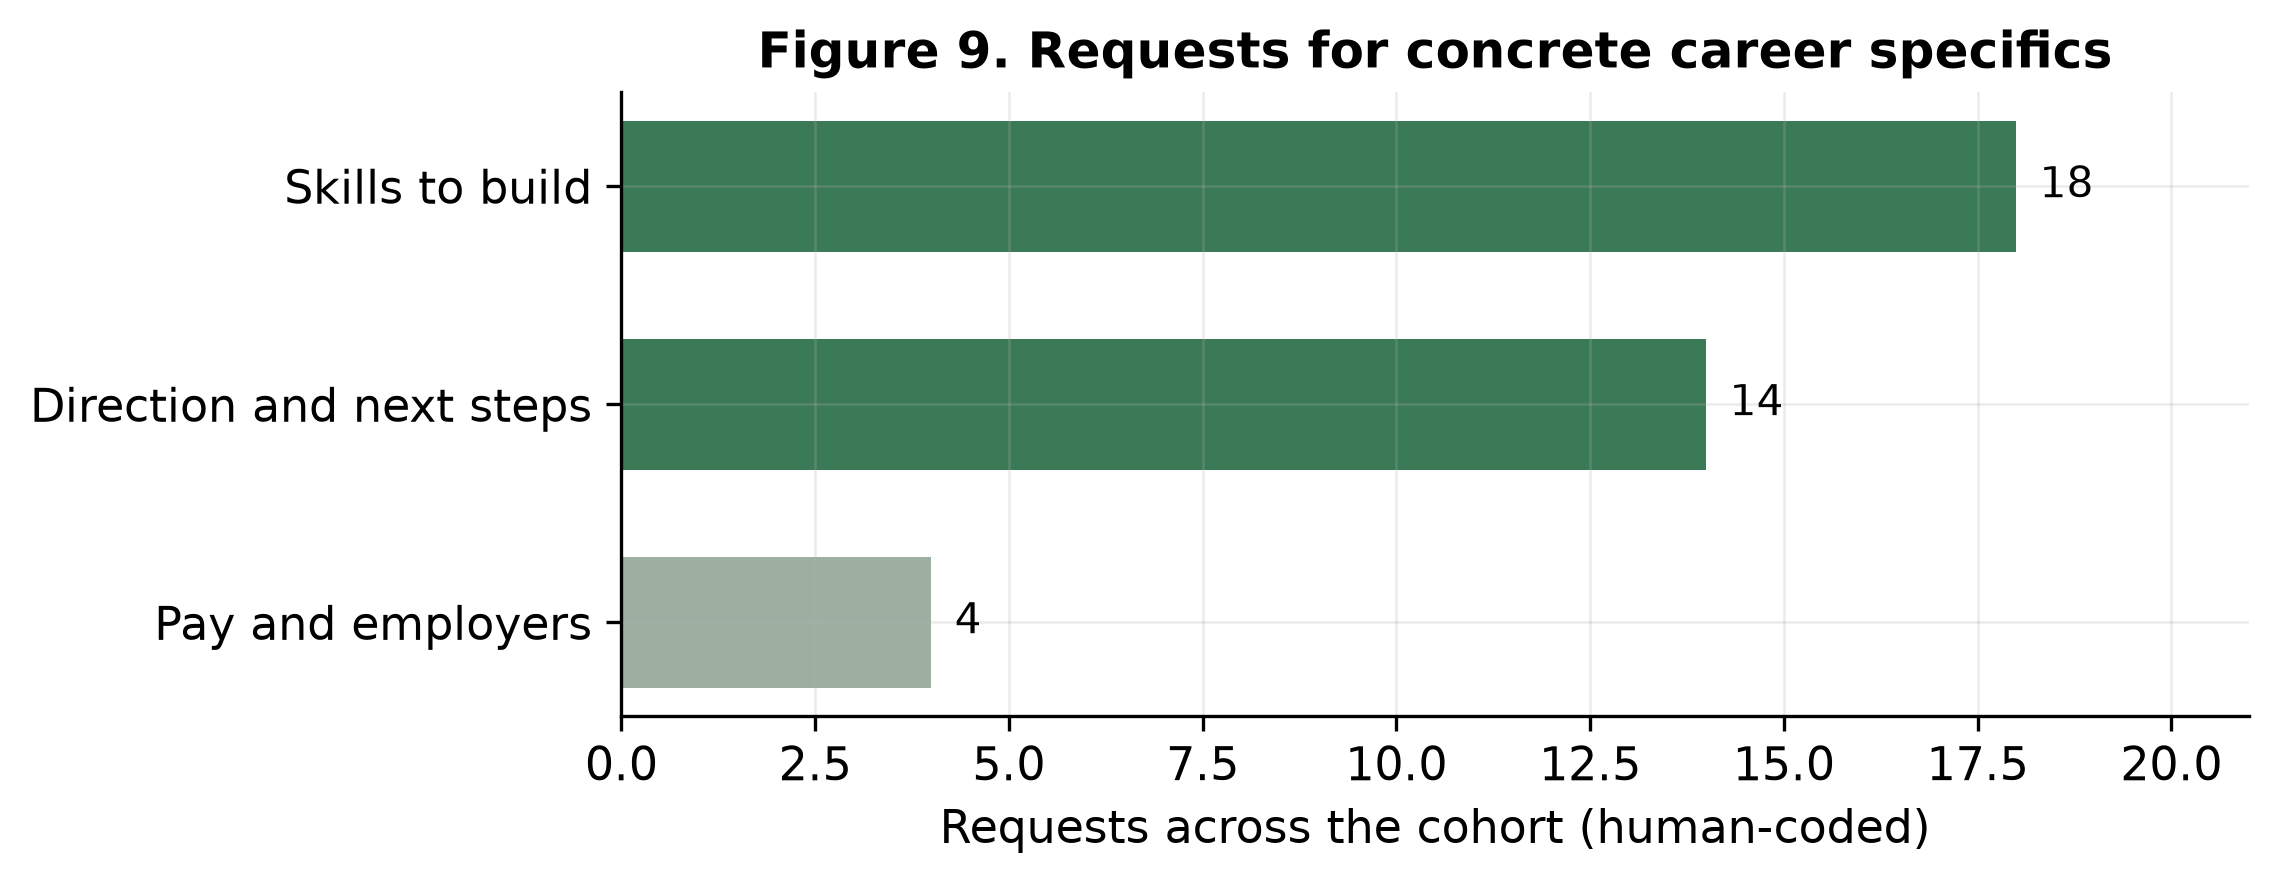

In [8]:
table, rel_pairs = Q.load_coding_table()
felt = Q.felt_real_codes_by_arm(table, sample)
words = Q.open_ended_word_counts(sample)
kap = Q.cohen_kappa(rel_pairs)
print("Positive codes on 'what felt real' (32 cohort):")
for arm in ["integrated","baseline"]:
    c = felt[arm]; print(f"  {arm:10}: Σ={sum(c.values())}  "
        f"resonance(P1)={c['P1']} vivid(P2)={c['P2']} continuity(P3)={c['P3']} agency(P5)={c['P5']}")
print(f"Inter-rater reliability: Cohen's κ = {kap['kappa']:.2f} (n={kap['n']}, "
      f"{kap['observed_agreement']:.0%} agreement)")
for arm in ["integrated","baseline"]:
    w = words[arm]; print(f"  {arm:10}: wrote felt-real {w['wrote_felt_real']}/{w['n']} "
        f"({w['pct_felt_real']:.0f}%), mean words real={w['mean_words_real']:.0f} broke={w['mean_words_broke']:.0f}")
F.fig8_qualitative(felt, words); display(Image("figures/fig8_open_ended.png"))
F.fig9_requests(Q.HUMAN_CODED_REQUESTS); Image("figures/fig9_requests.png")

## 8 · Value-adding robustness analyses  *(extensions)*

These strengthen a between-arm **null** to top-journal standard. None changes the
thesis's conclusions; they make them precise.

* **Equivalence (TOST).** With n=32 the 90% CIs do not fall inside ±0.5, so the arms are **“not significantly different”, not positively equivalent** — i.e. the nulls are *absence of evidence*, consistent with the thesis's “not detectable under this model and sample”.
* **Bayes factors (JZS).** BF₀₁ ≈ 1.4–2.9: only *anecdotal* evidence for the null — the data are genuinely inconclusive, as a power analysis predicts.
* **Minimum-turn sensitivity (0–5).** Re-running every comparison at each inclusion threshold leaves direction and significance unchanged (reproduces §6.4).
* **Multiplicity (Holm / BH).** No hypothesis survives correction (none was significant to begin with).
* **Casing-mirror adherence.** The integrated prompt says to mirror register “down to loose capitalisation”, yet the model almost never echoes an all-lowercase user — concrete evidence for the §8.3 “the model dropped the components” reading.

Equivalence (TOST, ±0.5):


,d,CI90,p_tost,equivalent
construct,,,,
closeness,-0.10,"[-0.69,+0.49]",0.130,False
vividness,-0.22,"[-0.81,+0.37]",0.217,False
continuity,-0.14,"[-0.73,+0.45]",0.156,False
cip_anxiety,0.13,"[-0.46,+0.72]",0.149,False
cip_confidence,-0.51,"[-1.11,+0.08]",0.513,False



Bayesian between-arm test:


,bf10,bf01
construct,,
closeness,0.35,2.87
vividness,0.40,2.53
continuity,0.36,2.78
cip_anxiety,0.36,2.81
cip_confidence,0.73,1.38



Multiplicity-corrected p-values:


,H,d,p,p_holm,p_bh
construct,,,,,
closeness,H1,-0.099,0.785,1.000,0.785
vividness,H2,-0.221,0.527,1.000,0.785
continuity,H3,-0.139,0.693,1.000,0.785
cip_anxiety,H4a,0.128,0.715,1.000,0.785
cip_confidence,H4b,-0.512,0.166,0.829,0.785



Minimum-turn sensitivity — # significant between-arm effects at each threshold:


min_turns,0,1,2,3,4,5
n_significant,0,0,0,0,0,0



Casing-mirror adherence (integrated): 1 of 21 all-lowercase user messages were echoed (5%).


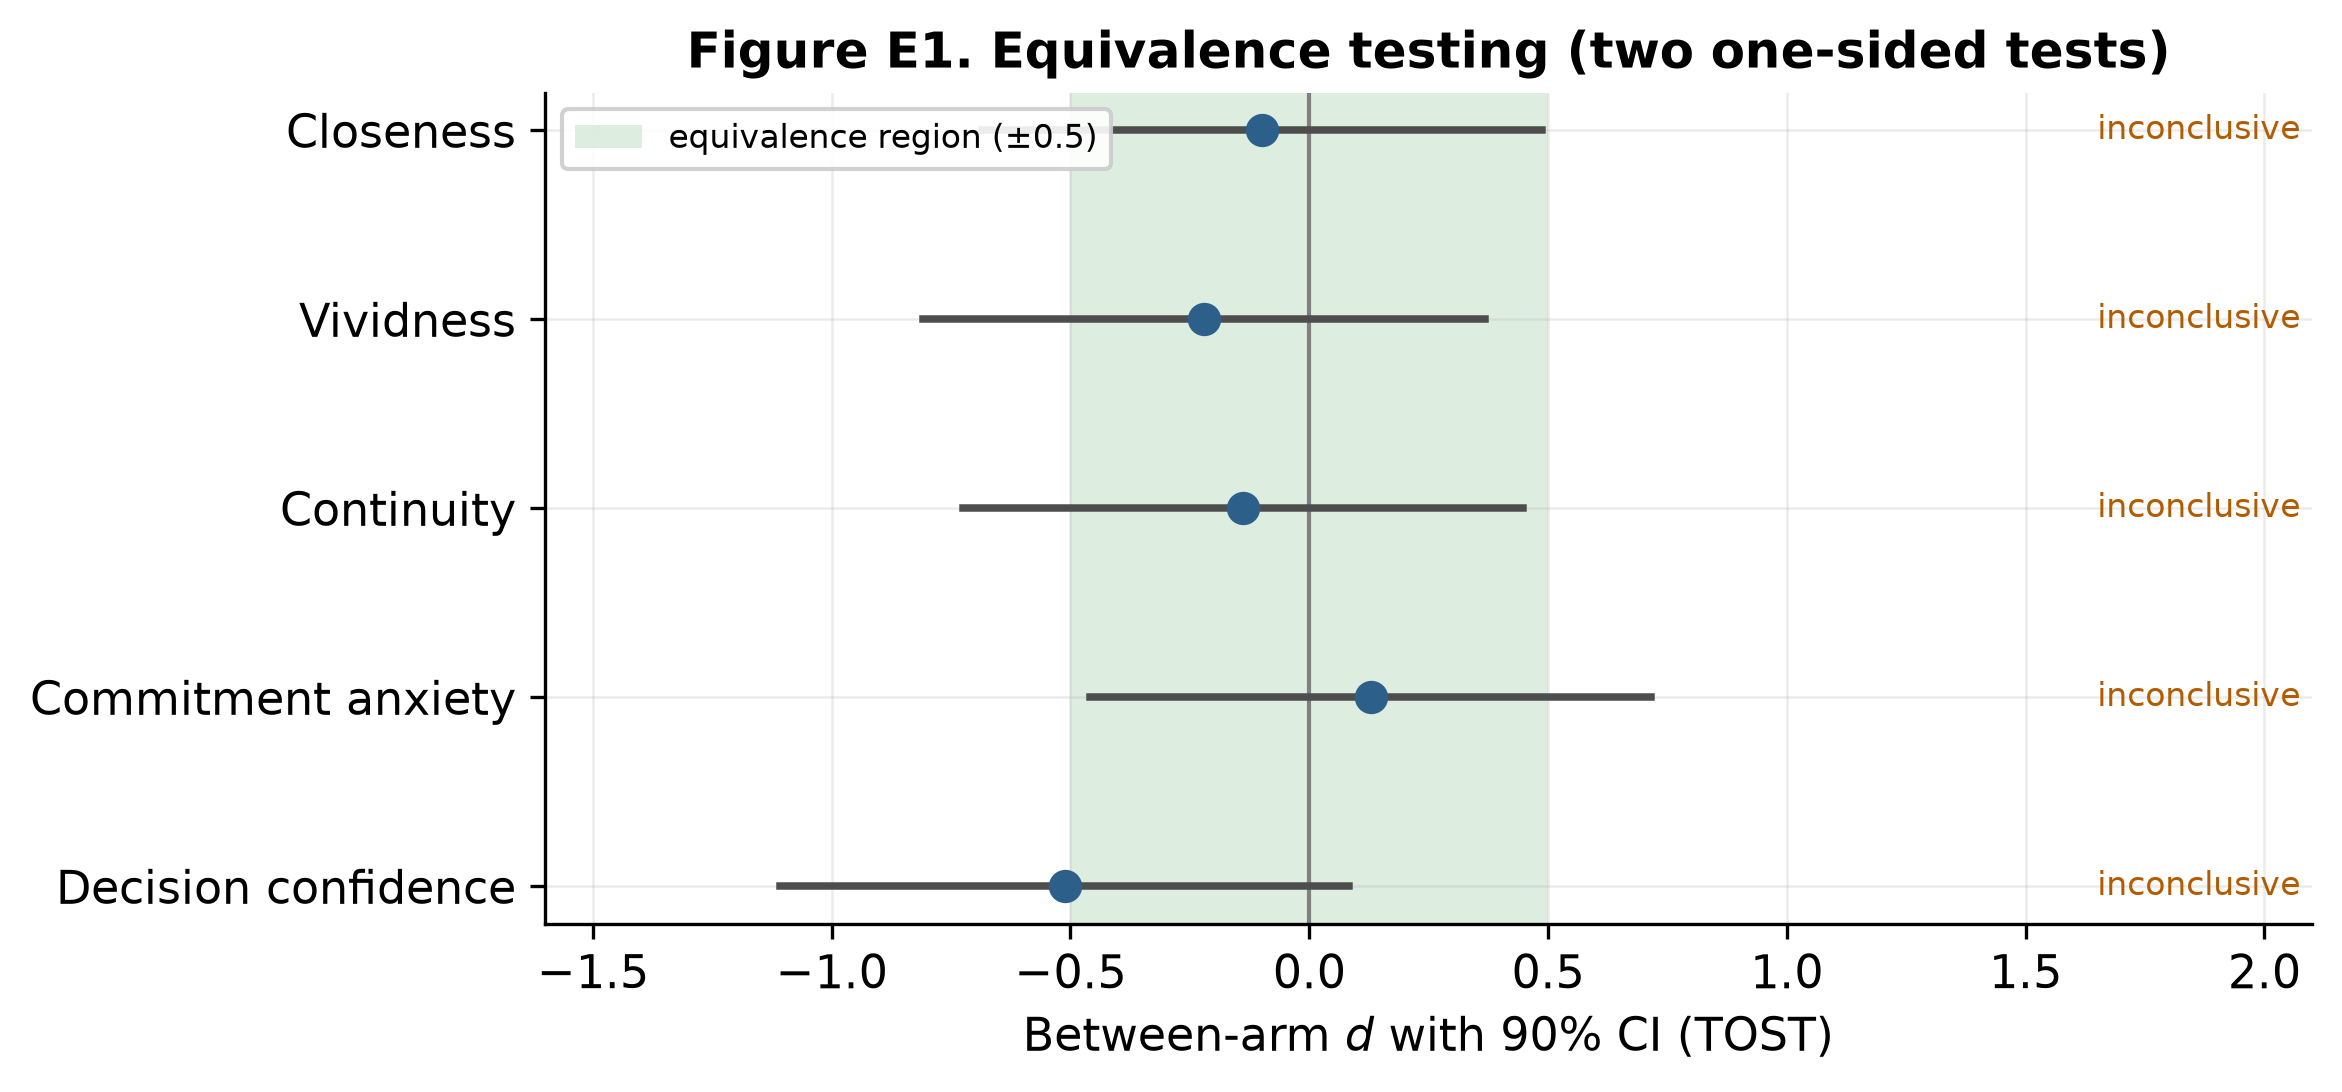

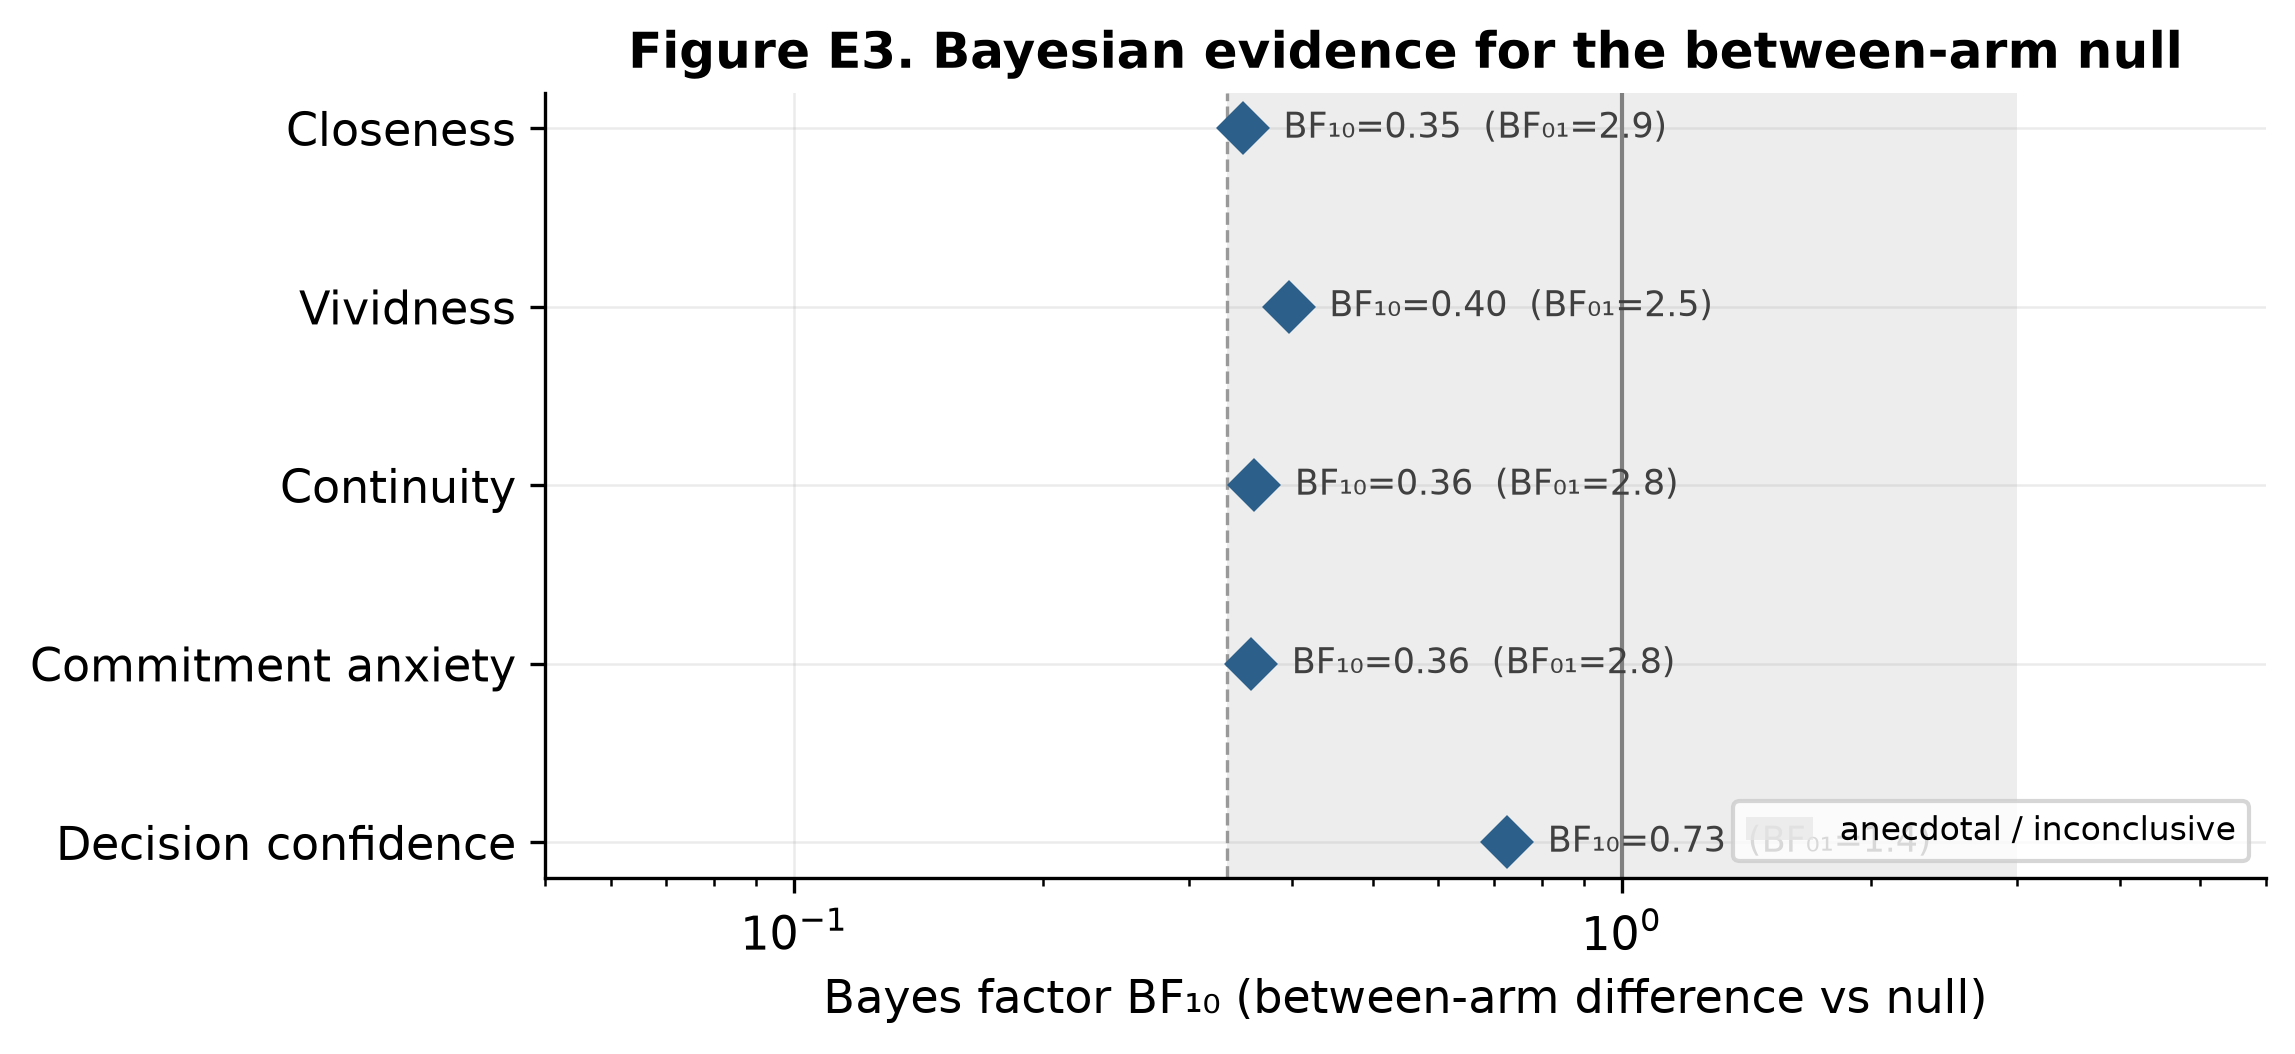

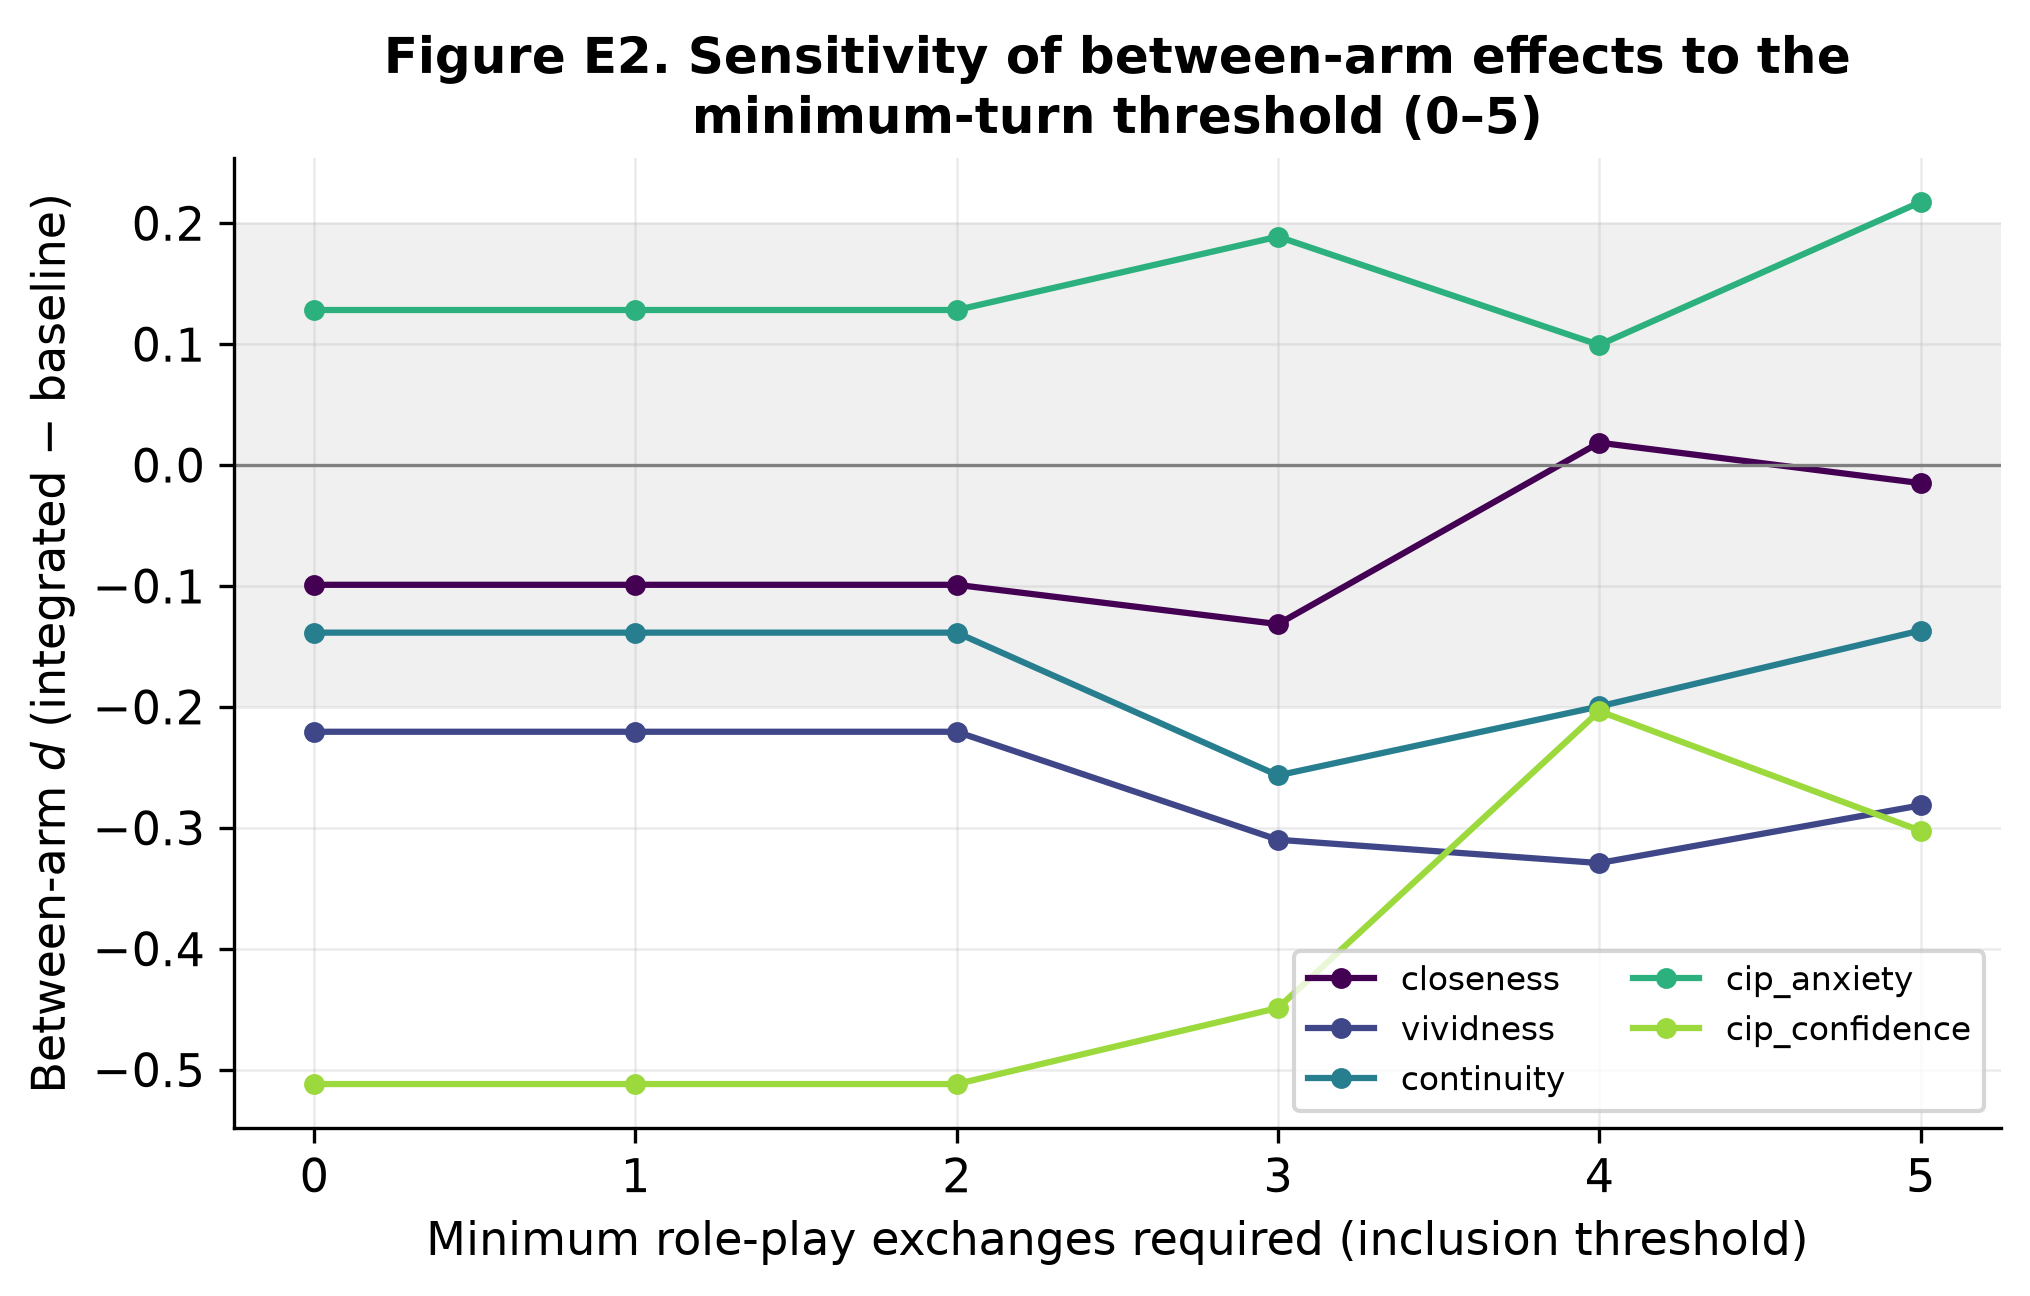

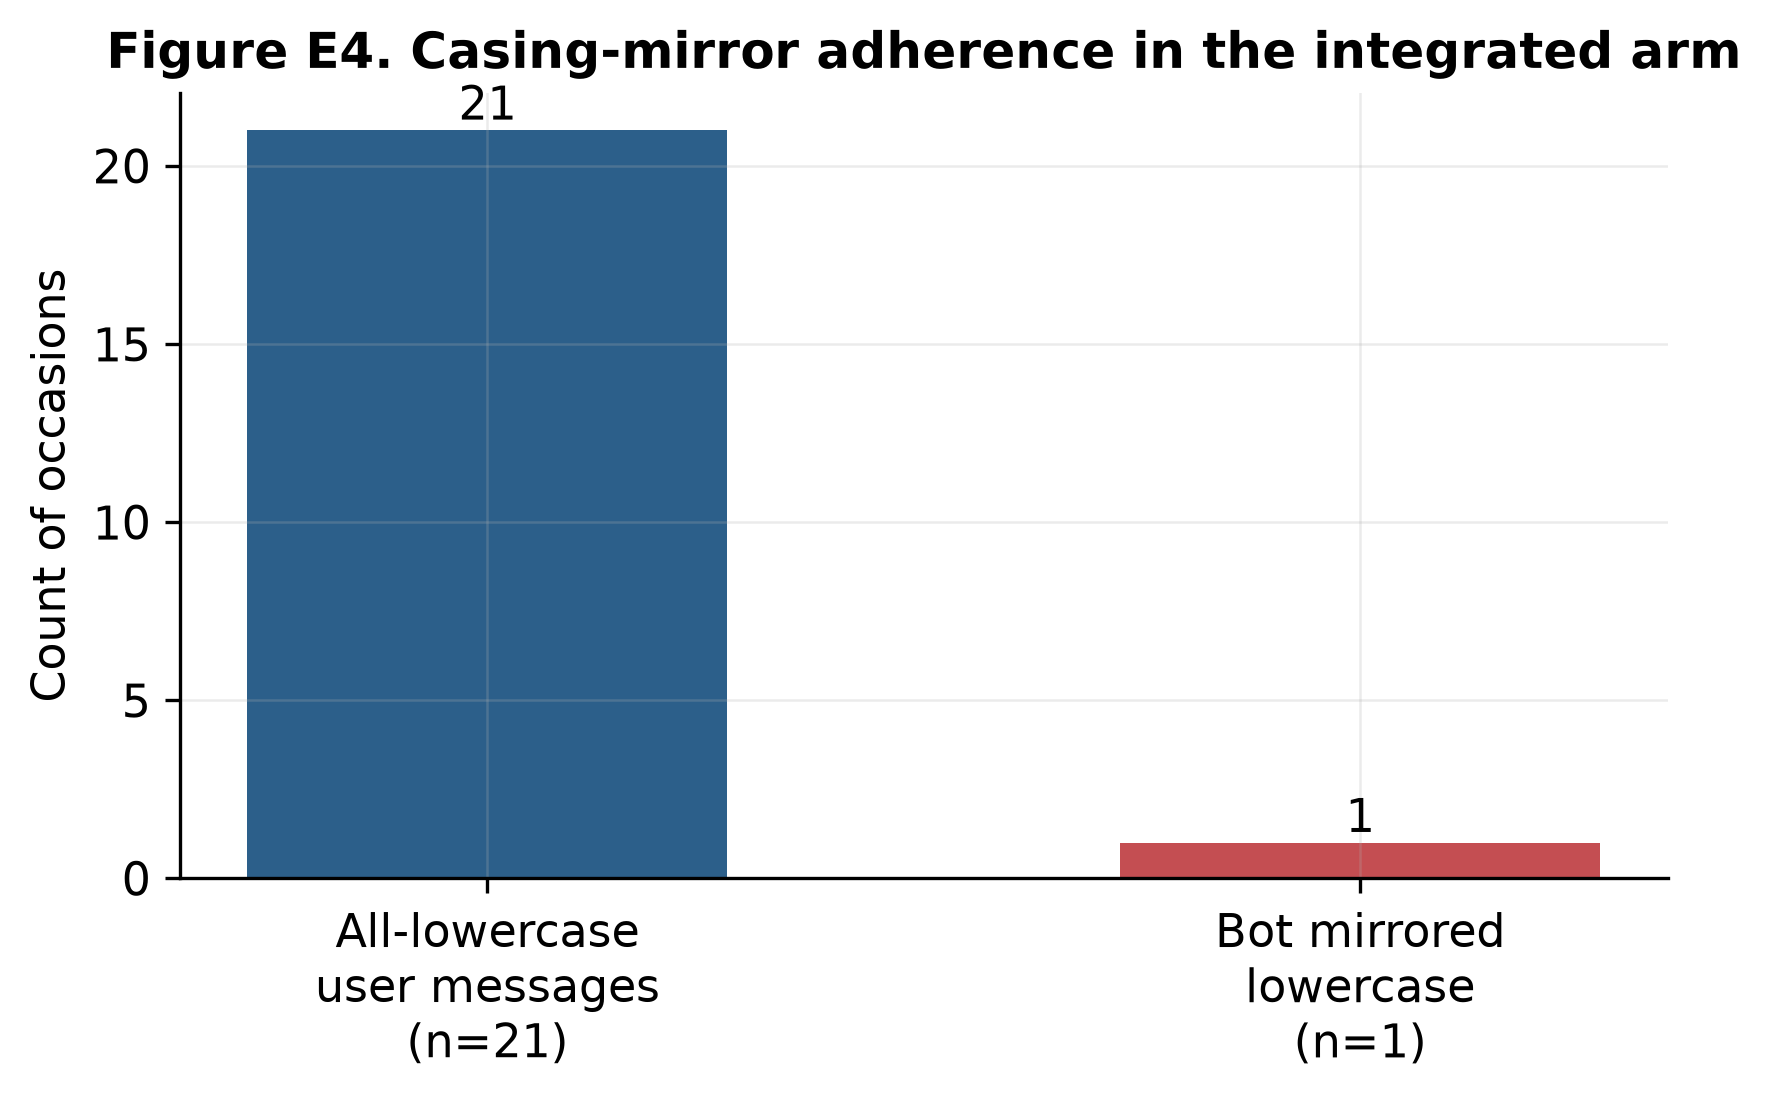

In [9]:
tost  = X.tost_equivalence(df, bound=0.5)
bayes = X.bayes_between_arms(df, between)
mult  = X.multiplicity(between)
sens  = X.minturn_sensitivity(studies)
casing = X.casing_mirror_adherence(sample)

print("Equivalence (TOST, ±0.5):")
display(tost.assign(d=tost.d.round(2), CI90=tost.apply(lambda r:f"[{r.ci90_lo:+.2f},{r.ci90_hi:+.2f}]",axis=1))
        [["construct","d","CI90","p_tost","equivalent"]].round(3).set_index("construct"))
print("\nBayesian between-arm test:")
display(bayes.assign(bf10=bayes.bf10.round(2), bf01=bayes.bf01.round(2))[["construct","bf10","bf01"]].set_index("construct"))
print("\nMultiplicity-corrected p-values:")
display(mult.round(3).set_index("construct"))
print("\nMinimum-turn sensitivity — # significant between-arm effects at each threshold:")
display(sens.groupby("min_turns").significant.sum().rename("n_significant").to_frame().T)
print(f"\nCasing-mirror adherence (integrated): {casing['bot_mirrored_lowercase']} of "
      f"{casing['lowercase_user_messages']} all-lowercase user messages were echoed "
      f"({casing['mirror_rate']:.0%}).")
for fn, a in [(F.figE1_equivalence, tost), (F.figE3_bayes, bayes), (F.figE2_sensitivity, sens), (F.figE4_casing, casing)]:
    fn(a)
from IPython.display import display as _d
for n in ["figE1_equivalence","figE3_bayes","figE2_sensitivity","figE4_casing_adherence"]:
    _d(Image(f"figures/{n}.png"))

## 9 · Self-check — does the reproduction match the thesis?

A machine-checkable assertion that the regenerated numbers equal the values
reported in the thesis (within rounding). If every line says `OK`, the
reproduction is faithful.

In [10]:
def approx(a, b, tol): return abs(a - b) <= tol
checks = []
b = {r.construct: r for r in between.itertuples()}
w = {r.construct: r for r in whole.itertuples()}
checks.append(("n = 32 (18/14)", counts["final_analysis_sample"]==32 and counts["_final_by_arm"]=={'integrated':18,'baseline':14}))
checks.append(("Closeness d=-0.10, t(27)=-0.28",      approx(b['closeness'].d,-0.10,.02) and approx(b['closeness'].t,-0.28,.05) and round(b['closeness'].df)==27))
checks.append(("Vividness d=-0.22, p=.53",            approx(b['vividness'].d,-0.22,.02) and approx(b['vividness'].p,.527,.02)))
checks.append(("Continuity d=-0.14, p=.69",           approx(b['continuity'].d,-0.14,.02) and approx(b['continuity'].p,.69,.03)))
checks.append(("Indecision d=+0.13, p=.72",           approx(b['cip_anxiety'].d,0.13,.02) and approx(b['cip_anxiety'].p,.72,.03)))
checks.append(("Self-efficacy d=-0.51, t(27)=-1.42",  approx(b['cip_confidence'].d,-0.51,.02) and approx(b['cip_confidence'].t,-1.42,.05) and round(b['cip_confidence'].df)==27))
checks.append(("Whole-sample vividness dz=0.73, p<.001", approx(w['vividness'].dz,0.73,.02) and w['vividness'].p<.001))
checks.append(("Whole-sample closeness dz=0.40, p=.03",  approx(w['closeness'].dz,0.40,.02) and approx(w['closeness'].p,.032,.01)))
checks.append(("Manip checks 4.22/4.57, 4.22/4.29, 4.78/4.86",
               all(approx(manip.iloc[i].mean_int, v0,.05) and approx(manip.iloc[i].mean_base, v1,.05)
                   for i,(v0,v1) in enumerate([(4.22,4.57),(4.22,4.29),(4.78,4.86)]))))
checks.append(("LSM grand mean ≈ 0.62, arms n.s.", approx((Lr['integrated_mean']*18+Lr['baseline_mean']*14)/32,0.62,.02) and Lr['p']>.05))
checks.append(("Coupling r=0.31, p=.09",  approx(coupling['r'],0.31,.02) and approx(coupling['p'],.086,.02)))
checks.append(("Coded positive codes 18 vs 11; vivid 3 vs 0",
               sum(felt['integrated'].values())==18 and sum(felt['baseline'].values())==11
               and felt['integrated']['P2']==3 and felt['baseline']['P2']==0))
checks.append(("Open-ended words 25/17 (real), 30/13 (broke)",
               approx(words['integrated']['mean_words_real'],25,1) and approx(words['baseline']['mean_words_real'],17,1)
               and approx(words['integrated']['mean_words_broke'],30,1) and approx(words['baseline']['mean_words_broke'],13,1)))
checks.append(("Cohen's κ = 1.00", approx(kap['kappa'],1.0,.001)))
checks.append(("Min-turn sensitivity: 0 significant at every threshold 0–5", sens.significant.sum()==0))

ok = sum(c[1] for c in checks)
for name, passed in checks:
    print(("  OK  " if passed else "  ✗✗  ") + name)
print(f"\n{ok}/{len(checks)} checks passed."
      + ("  ✅ Reproduction is faithful." if ok==len(checks) else "  ⚠ see failures above."))
assert ok == len(checks), "reproduction mismatch"

  OK  n = 32 (18/14)
  OK  Closeness d=-0.10, t(27)=-0.28
  OK  Vividness d=-0.22, p=.53
  OK  Continuity d=-0.14, p=.69
  OK  Indecision d=+0.13, p=.72
  OK  Self-efficacy d=-0.51, t(27)=-1.42
  OK  Whole-sample vividness dz=0.73, p<.001
  OK  Whole-sample closeness dz=0.40, p=.03
  OK  Manip checks 4.22/4.57, 4.22/4.29, 4.78/4.86
  OK  LSM grand mean ≈ 0.62, arms n.s.
  OK  Coupling r=0.31, p=.09
  OK  Coded positive codes 18 vs 11; vivid 3 vs 0
  OK  Open-ended words 25/17 (real), 30/13 (broke)
  OK  Cohen's κ = 1.00
  OK  Min-turn sensitivity: 0 significant at every threshold 0–5

15/15 checks passed.  ✅ Reproduction is faithful.


## 10 · Summary

The integrated, theory-mapped future-self chatbot **did not outperform** a
minimal-but-sincere baseline on closeness, vividness, continuity, career
decision self-efficacy, or career indecision (all between-arm |d| ≤ 0.51, all
CIs spanning zero; nothing survives multiplicity correction; Bayes factors only
anecdotally favour the null; equivalence is not established — the study is
powered only for large effects). The manipulation checks and an objective style
measure show the two arms were **not perceived as different**, locating the null
at the *perceptibility / delivery* of the added components — most plausibly
because the provided model (GPT-5.1 via the university proxy) applied them
unevenly (the casing-mirror analysis shows an explicit, visible instruction
being followed ≈0% of the time). Yet the future-self conversation itself
**worked**: pooled across arms it raised vividness (d_z = 0.73) and closeness
(d_z = 0.40), and the integrated arm drew longer, richer open-ended responses
with the only vivid-scene moments. The active ingredients of a future self that
feels real are **specificity, present-to-future continuity, and emotional
honesty**; the dominant failure mode is the drift to generic reassurance shared
by both arms.

*All numbers above were regenerated from the live study database (or the bundled
de-identified snapshot) by this notebook and machine-checked against the thesis
in §9.*